In [1]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt

#### load data

In [3]:
car_price_df = pd.read_csv("car_price_prediction.csv") # data structure called frame

In [4]:
# inspect data
car_price_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [5]:
car_price_df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')

#### clean data

In [7]:
# rename columns
car_price_df = car_price_df.rename(columns={
    'Price': 'price',
    'Levy': 'levy',
    'Model': 'model',
    'Prod. year': 'production_year',
    'Fuel type': 'fuel_type',
    'Engine volume': 'engine_volume',
    'Mileage': 'mileage',
    'Cylinders': 'cylinders',
    'Airbags': 'airbags',
    'Manufacturer': 'manufacturer'
})

car_price_df.head()

,ID,price,levy,manufacturer,model,production_year,Category,Leather interior,fuel_type,engine_volume,mileage,cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [8]:
# view data structure
car_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   price             19237 non-null  int64  
 2   levy              19237 non-null  object 
 3   manufacturer      19237 non-null  object 
 4   model             19237 non-null  object 
 5   production_year   19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   fuel_type         19237 non-null  object 
 9   engine_volume     19237 non-null  object 
 10  mileage           19237 non-null  object 
 11  cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

#### clean data

In [10]:
# remove characters not needed
car_price_df['levy'] = car_price_df['levy'].str.replace('-', '0', regex=False)
car_price_df['mileage'] = car_price_df['mileage'].str.replace('km', '', regex=False)
car_price_df['mileage'] = car_price_df['mileage'].apply(lambda x: x.strip()).apply(lambda x: int(x))
car_price_df['engine_volume'] = car_price_df['engine_volume'].str.replace('Turbo', '', regex=False)
car_price_df = car_price_df.astype({'levy': float, 'engine_volume': float})

car_price_df.head()


,ID,price,levy,manufacturer,model,production_year,Category,Leather interior,fuel_type,engine_volume,mileage,cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,airbags
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,0.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


#### visualize data

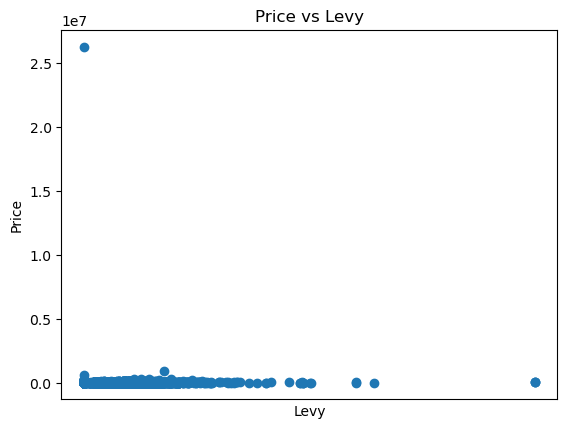

In [12]:

import matplotlib.pyplot as plt
import numpy as np

# price and levy
plt.scatter(car_price_df['levy'], car_price_df['price'])
plt.xlabel("Levy")
plt.ylabel("Price")
plt.title("Price vs Levy")
plt.xticks([]) 
# plt.yticks([])

plt.show()


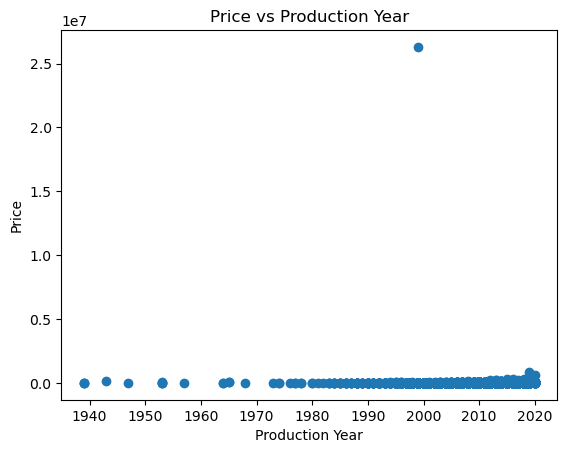

In [13]:
# production year and price

plt.scatter(car_price_df['production_year'], car_price_df['price'])
plt.xlabel("Production Year")
plt.ylabel("Price")
plt.title("Price vs Production Year")
plt.show()

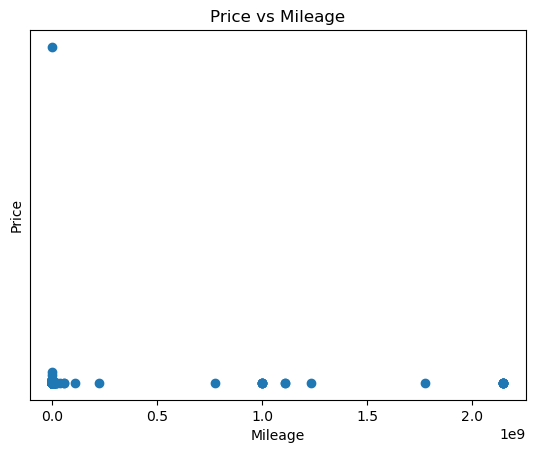

In [14]:
# mileage and price

plt.scatter(car_price_df['mileage'], car_price_df['price'])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Price vs Mileage")
plt.xticks() 
plt.yticks([])

plt.show()

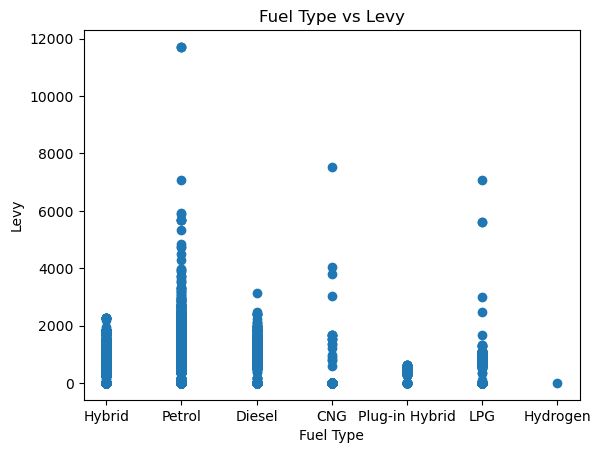

In [15]:
# Fuel Type and Levy

plt.scatter(car_price_df['fuel_type'], car_price_df['levy'])
plt.xlabel("Fuel Type")
plt.ylabel("Levy")
plt.title("Fuel Type vs Levy")
plt.show()

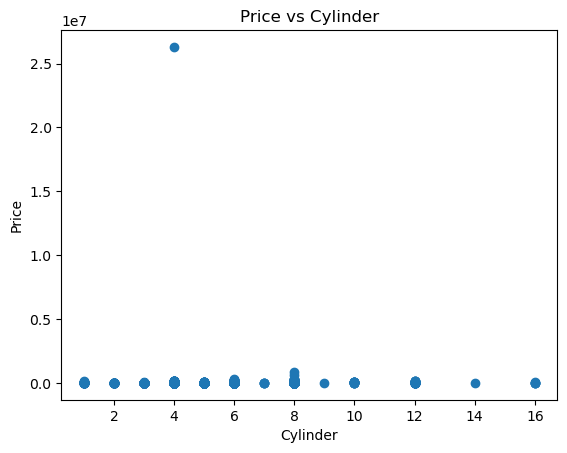

In [16]:
# levy and cylinder

plt.scatter(car_price_df['cylinders'], car_price_df['price'])
plt.xlabel("Cylinder")
plt.ylabel("Price")
plt.title("Price vs Cylinder")
plt.show()

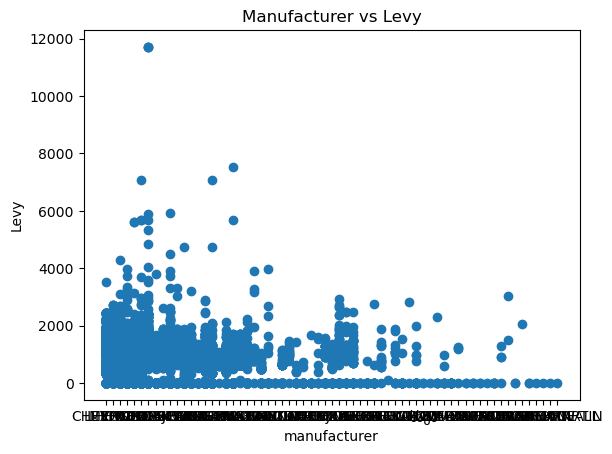

In [17]:
# Manufacturer and Levy

plt.scatter(car_price_df['manufacturer'], car_price_df['levy'])
plt.xlabel("manufacturer")
plt.ylabel("Levy")
plt.title("Manufacturer vs Levy")
plt.show()

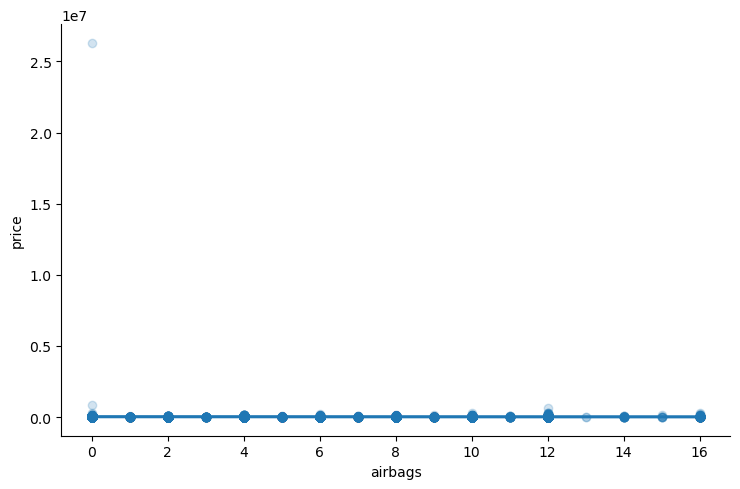

In [18]:
import seaborn as sns

sns.lmplot(x='airbags', y='price', data=car_price_df, aspect=1.5, scatter_kws={'alpha': 0.2})

#### select label and features to model

In [20]:
feature_cols = ['production_year', 'levy', 'mileage', 'cylinders', 'airbags']
label_cols = ['price']

X = car_price_df[feature_cols]
y = car_price_df[label_cols]


### model data

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# instantiate a new model and fit the model to the data
linreg = LinearRegression().fit(X_train, y_train)
linreg


LinearRegression()

In [23]:
# display coefficients
print("Intercept: {}".format(linreg.intercept_))
print("Coefficients: {}".format(linreg.coef_))

Intercept: [-1424498.79589682]
Coefficients: [[ 7.16735554e+02 -5.30021044e+00 -2.92021101e-06  2.60103491e+03
  -9.62766234e+02]]


In [24]:
# make predictions using test data
y_pred = linreg.predict(X_test)
y_pred

array([[18410.14266822],
       [20502.77253243],
       [24987.49603677],
       ...,
       [17599.28198428],
       [19545.75678905],
       [20295.95023643]])

In [25]:

print(f"\nR² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")



R² Score: 0.071
MSE: 287776517.609
RMSE: 16963.977


In [26]:
import joblib

joblib.dump(linreg, "car_price_model.pkl")

['car_price_model.pkl']

In [27]:
import pickle

pickle.dump(linreg, open('linreg.pkl', 'wb'))

In [28]:
import json

features = list(X.columns)
json.dump(features, open('features.json', 'w'))

In [58]:
pickle.dump(X.columns, open('columns.pkl', 'wb'))

In [62]:
print(linreg)

LinearRegression()
